# 04 — All-layer learned-mixture comparison
Use all 12 officially accessible frozen DINOv3 transformer layers and learn four softmax mixtures (48 scalar logits) for the unchanged common decoder. Compare against fixed-layer DINOv3 and extend notebook 03's DINOv3/V-JEPA result table without overwriting it.

In [4]:
# Fresh-kernel bootstrap. Edit only these settings; cached Drive assets are reused.
PROJECT_REPO_URL = 'https://github.com/papanag/cod-ssl.git'
PROJECT_BRANCH = 'main'
ACCEPT_COD10K_NONCOMMERCIAL_LICENSE = True

from google.colab import drive
drive.mount('/content/drive')
from getpass import getpass
from pathlib import Path
import json, os, subprocess, sys, torch
project_dir = Path('/content/cod-ssl')
if (project_dir / '.git').is_dir():
    subprocess.run(['git', '-C', str(project_dir), 'fetch', 'origin', PROJECT_BRANCH], check=True)
    subprocess.run(['git', '-C', str(project_dir), 'checkout', PROJECT_BRANCH], check=True)
    subprocess.run(['git', '-C', str(project_dir), 'pull', '--ff-only', 'origin', PROJECT_BRANCH], check=True)
else:
    subprocess.run(['git', 'clone', '--branch', PROJECT_BRANCH, PROJECT_REPO_URL, str(project_dir)], check=True)
subprocess.run([sys.executable, '-m', 'pip', 'install', '-e', f'{project_dir}[dev,notebooks]'], check=True)
bootstrap_env = os.environ.copy()
dino_weights = Path('/content/drive/MyDrive/cod-ssl/checkpoints/dinov3_vitb16.pth')
if not dino_weights.is_file():
    private_url = getpass('Private DINOv3 ViT-B/16 LVD-1689M URL: ').strip()
    if not private_url: raise ValueError('The approved DINOv3 URL is required.')
    bootstrap_env['COD_SSL_DINOV3_DOWNLOAD_URL'] = private_url
    del private_url
state_file = Path('/content/cod_ssl_bootstrap_state.json')
command = [sys.executable, str(project_dir / 'scripts/bootstrap_colab.py'),
           '--project-dir', str(project_dir), '--state-file', str(state_file)]
if not ACCEPT_COD10K_NONCOMMERCIAL_LICENSE:
    raise PermissionError('Review https://github.com/DengPingFan/SINet#9-license before accepting.')
command += ['--ensure-training-data', '--accept-noncommercial-license']
subprocess.run(command, cwd=project_dir, env=bootstrap_env, check=True)
state = json.loads(state_file.read_text())
os.environ.update(state['environment'])
PROJECT_DIR = Path(state['project_dir'])
DATA_ROOT = Path(state['data_root'])
RUNS_ROOT = Path(state['runs_root'])
COMPARISONS_ROOT = Path(state['comparisons_root'])
TRAIN_MANIFEST = Path(state['train_manifest'])
os.chdir(PROJECT_DIR)
print('Ready on', state['gpu'])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Ready on NVIDIA A100-SXM4-40GB


In [5]:
# Validate the same decontaminated protocol used by notebook 03.
exclusions = str(PROJECT_DIR / 'configs/dataset_exclusions.csv')
receipt = DATA_ROOT / 'validation/dataset_validation_v3.json'
commands = [
    [sys.executable, 'scripts/bootstrap_test_data.py', '--data-root', str(DATA_ROOT),
     '--manifest-dir', 'manifests', '--exclusions', exclusions, '--accept-noncommercial-license'],
    [sys.executable, 'scripts/validate_dataset.py', '--manifest-dir', 'manifests',
     '--exclusions', exclusions, '--receipt', str(receipt)],
]
for command in commands: subprocess.run(command, cwd=PROJECT_DIR, check=True)
os.sync()

In [6]:
# Stable Drive path and resumable 40-epoch DINOv3 all-layer training.
TAG = 'phase1_seed42_all12_mix4'
DINO_RUN = RUNS_ROOT / f'{TAG}_dinov3_vitb16'
FIXED_DINO_RUN = RUNS_ROOT / 'phase1_seed42_dinov3_vitb16'
FIXED_VJEPA_RUN = RUNS_ROOT / 'phase1_seed42_vjepa21_vitb16'
DINO_ABLATION = COMPARISONS_ROOT / f'{TAG}_dinov3_ablation'
EXTENDED_COMPARISON = COMPARISONS_ROOT / f'{TAG}_extended_03_results'
def train_or_resume(config, run_dir):
    last = run_dir / 'checkpoints/last.pt'
    if last.is_file(): print('Completed, skipping:', run_dir.name); return
    checkpoints = sorted((run_dir / 'checkpoints').glob('epoch_*.pt'))
    command = [sys.executable, 'scripts/train.py', '--config', config, '--run-dir', str(run_dir)]
    if checkpoints: command += ['--resume', str(checkpoints[-1])]
    subprocess.run(command, cwd=PROJECT_DIR, check=True)
train_or_resume('configs/all_layers_dinov3_vitb16.yaml', DINO_RUN)
os.sync()

Completed, skipping: phase1_seed42_all12_mix4_dinov3_vitb16


In [7]:
# Evaluate DINOv3 all-layer mixing and compare it directly with fixed-layer DINOv3.
metrics = DINO_RUN / 'metrics.json'
complete = metrics.is_file() and set(json.loads(metrics.read_text())) >= {'camo_test','cod10k_test','chameleon','nc4k'}
if not complete: subprocess.run([sys.executable, 'scripts/evaluate.py', '--run', str(DINO_RUN)], cwd=PROJECT_DIR, check=True)
subprocess.run([sys.executable, 'scripts/export_layer_mixture.py', '--run', str(DINO_RUN)], cwd=PROJECT_DIR, check=True)
subprocess.run([sys.executable, 'scripts/compare_runs.py', str(FIXED_DINO_RUN), str(DINO_RUN),
                '--output', str(DINO_ABLATION), '--qualitative-count', '24',
                '--labels', 'DINOv3 fixed [2,5,8,11]', 'DINOv3 all-12 mix-4'],
               cwd=PROJECT_DIR, check=True)
os.sync()

,model,dataset,s_measure,e_adaptive,weighted_f,mae,inference_ms_per_image
0,"DINOv3 fixed [2,5,8,11]",camo_test,0.888603,0.944316,0.859981,0.036849,23.638794
1,"DINOv3 fixed [2,5,8,11]",cod10k_test,0.872514,0.951917,0.802461,0.019866,20.904650
2,"DINOv3 fixed [2,5,8,11]",chameleon,0.908903,0.972230,0.868616,0.020611,21.298989
3,"DINOv3 fixed [2,5,8,11]",nc4k,0.895444,0.948927,0.858822,0.027333,21.996455
4,"V-JEPA official [2,5,8,11]",camo_test,0.859755,0.928368,0.822416,0.046073,51.635449
5,"V-JEPA official [2,5,8,11]",cod10k_test,0.836071,0.925938,0.737813,0.026309,49.345621
6,"V-JEPA official [2,5,8,11]",chameleon,0.893883,0.957426,0.846900,0.023939,49.204422
7,"V-JEPA official [2,5,8,11]",nc4k,0.873479,0.932736,0.823748,0.033763,49.813340
8,DINOv3 all-12 mix-4,camo_test,0.890589,0.945520,0.861654,0.036254,24.609158
9,DINOv3 all-12 mix-4,cod10k_test,0.871957,0.947555,0.800620,0.020298,21.924595


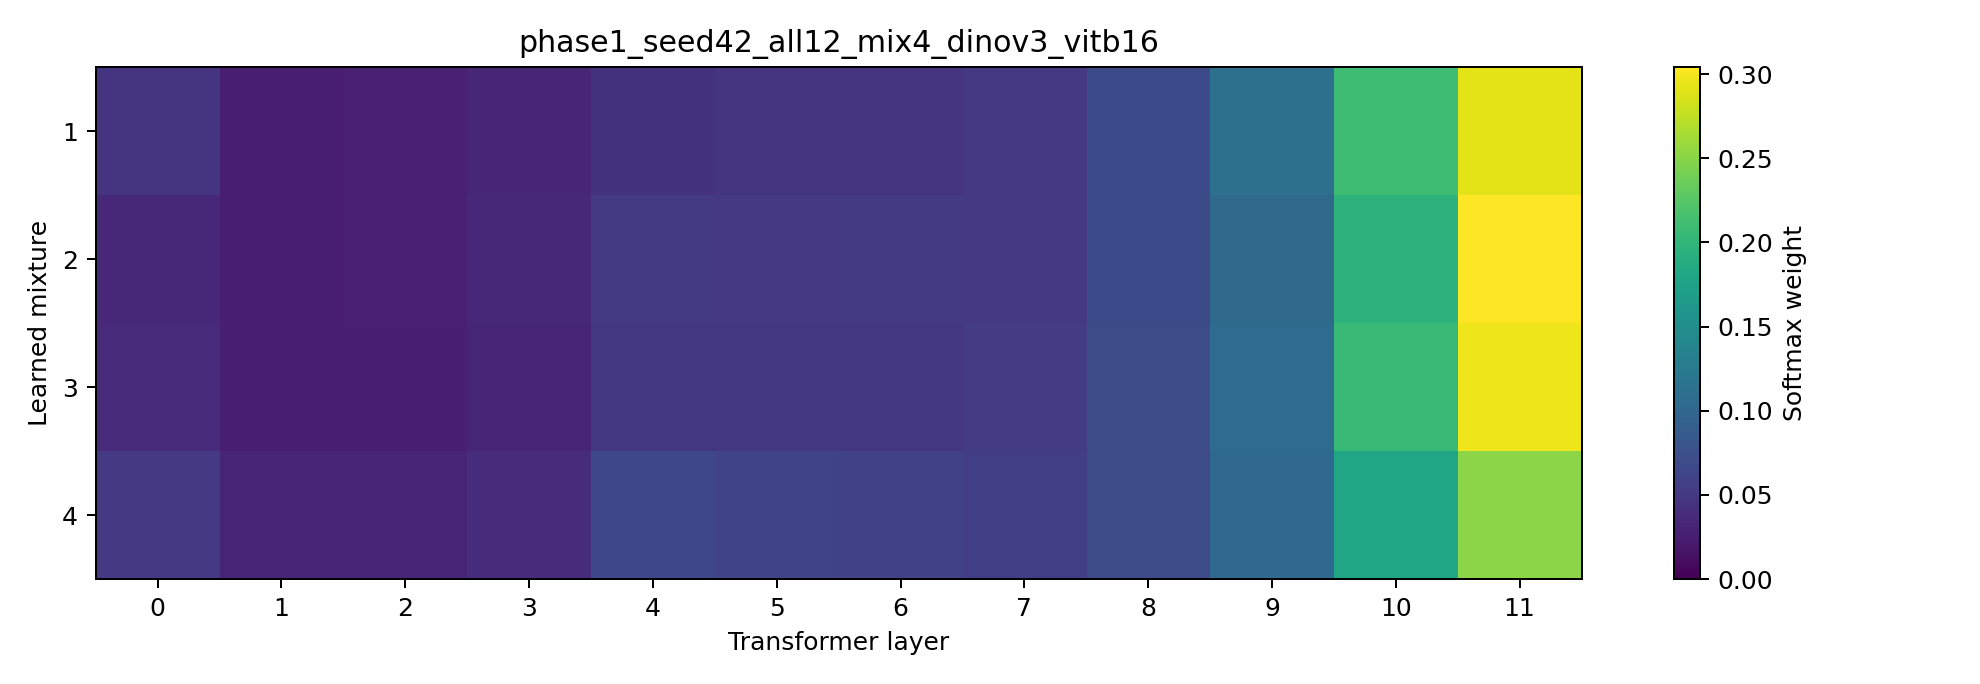

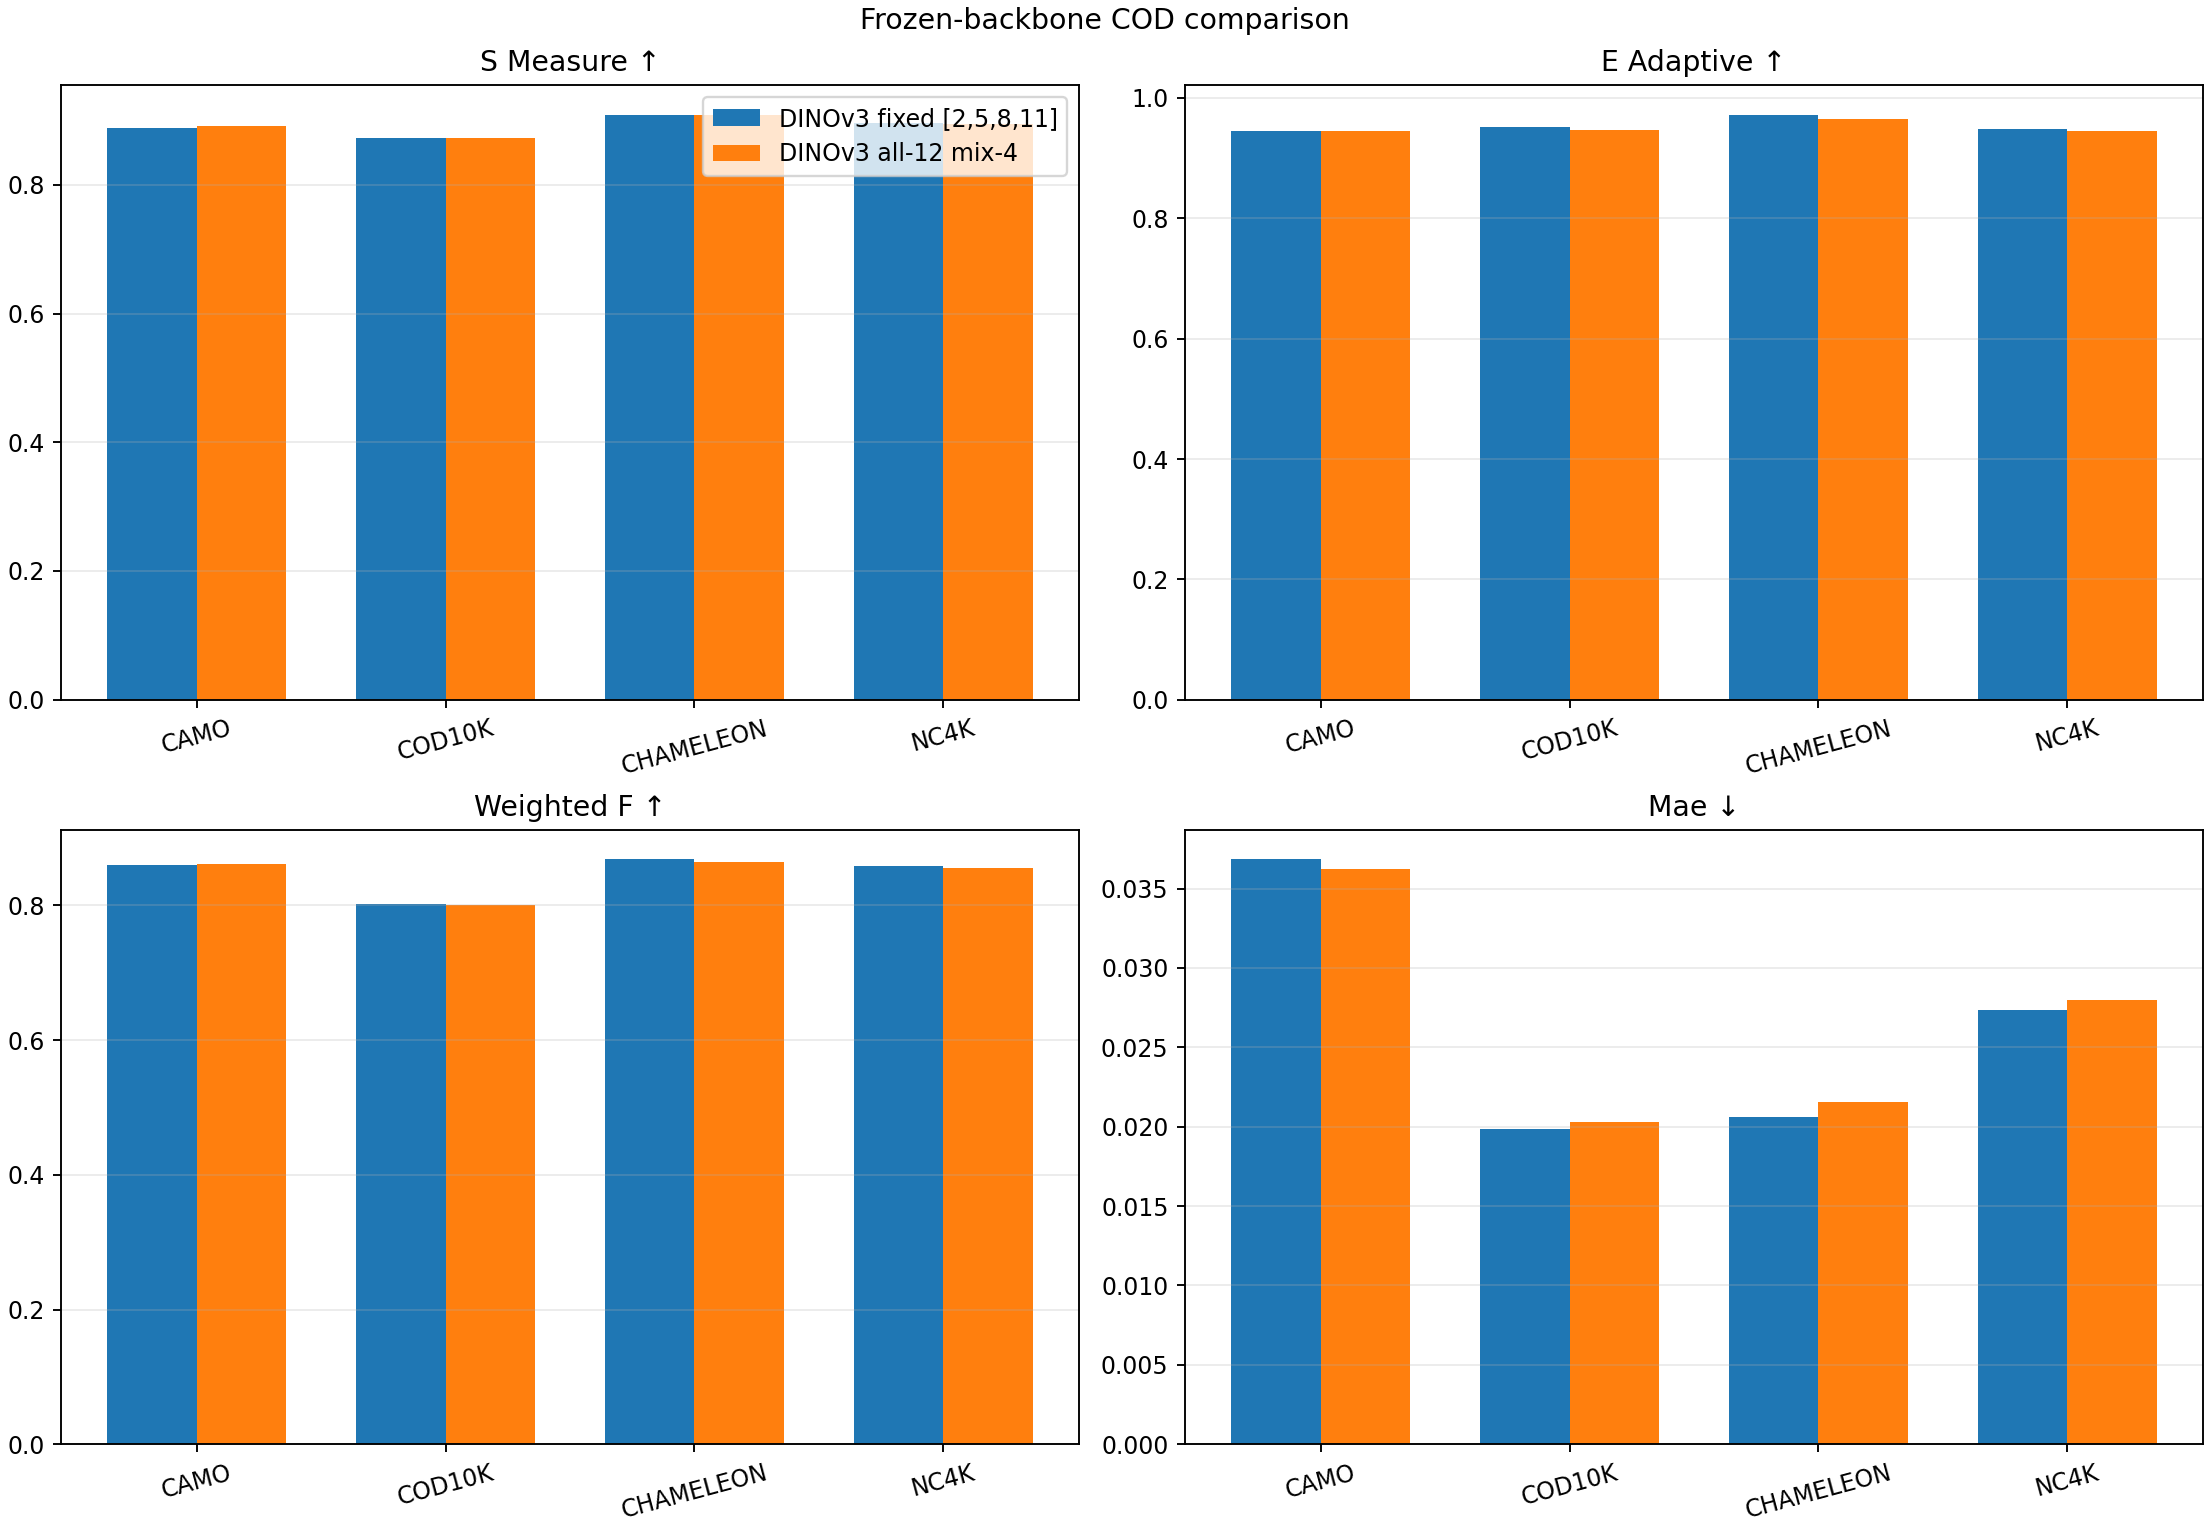

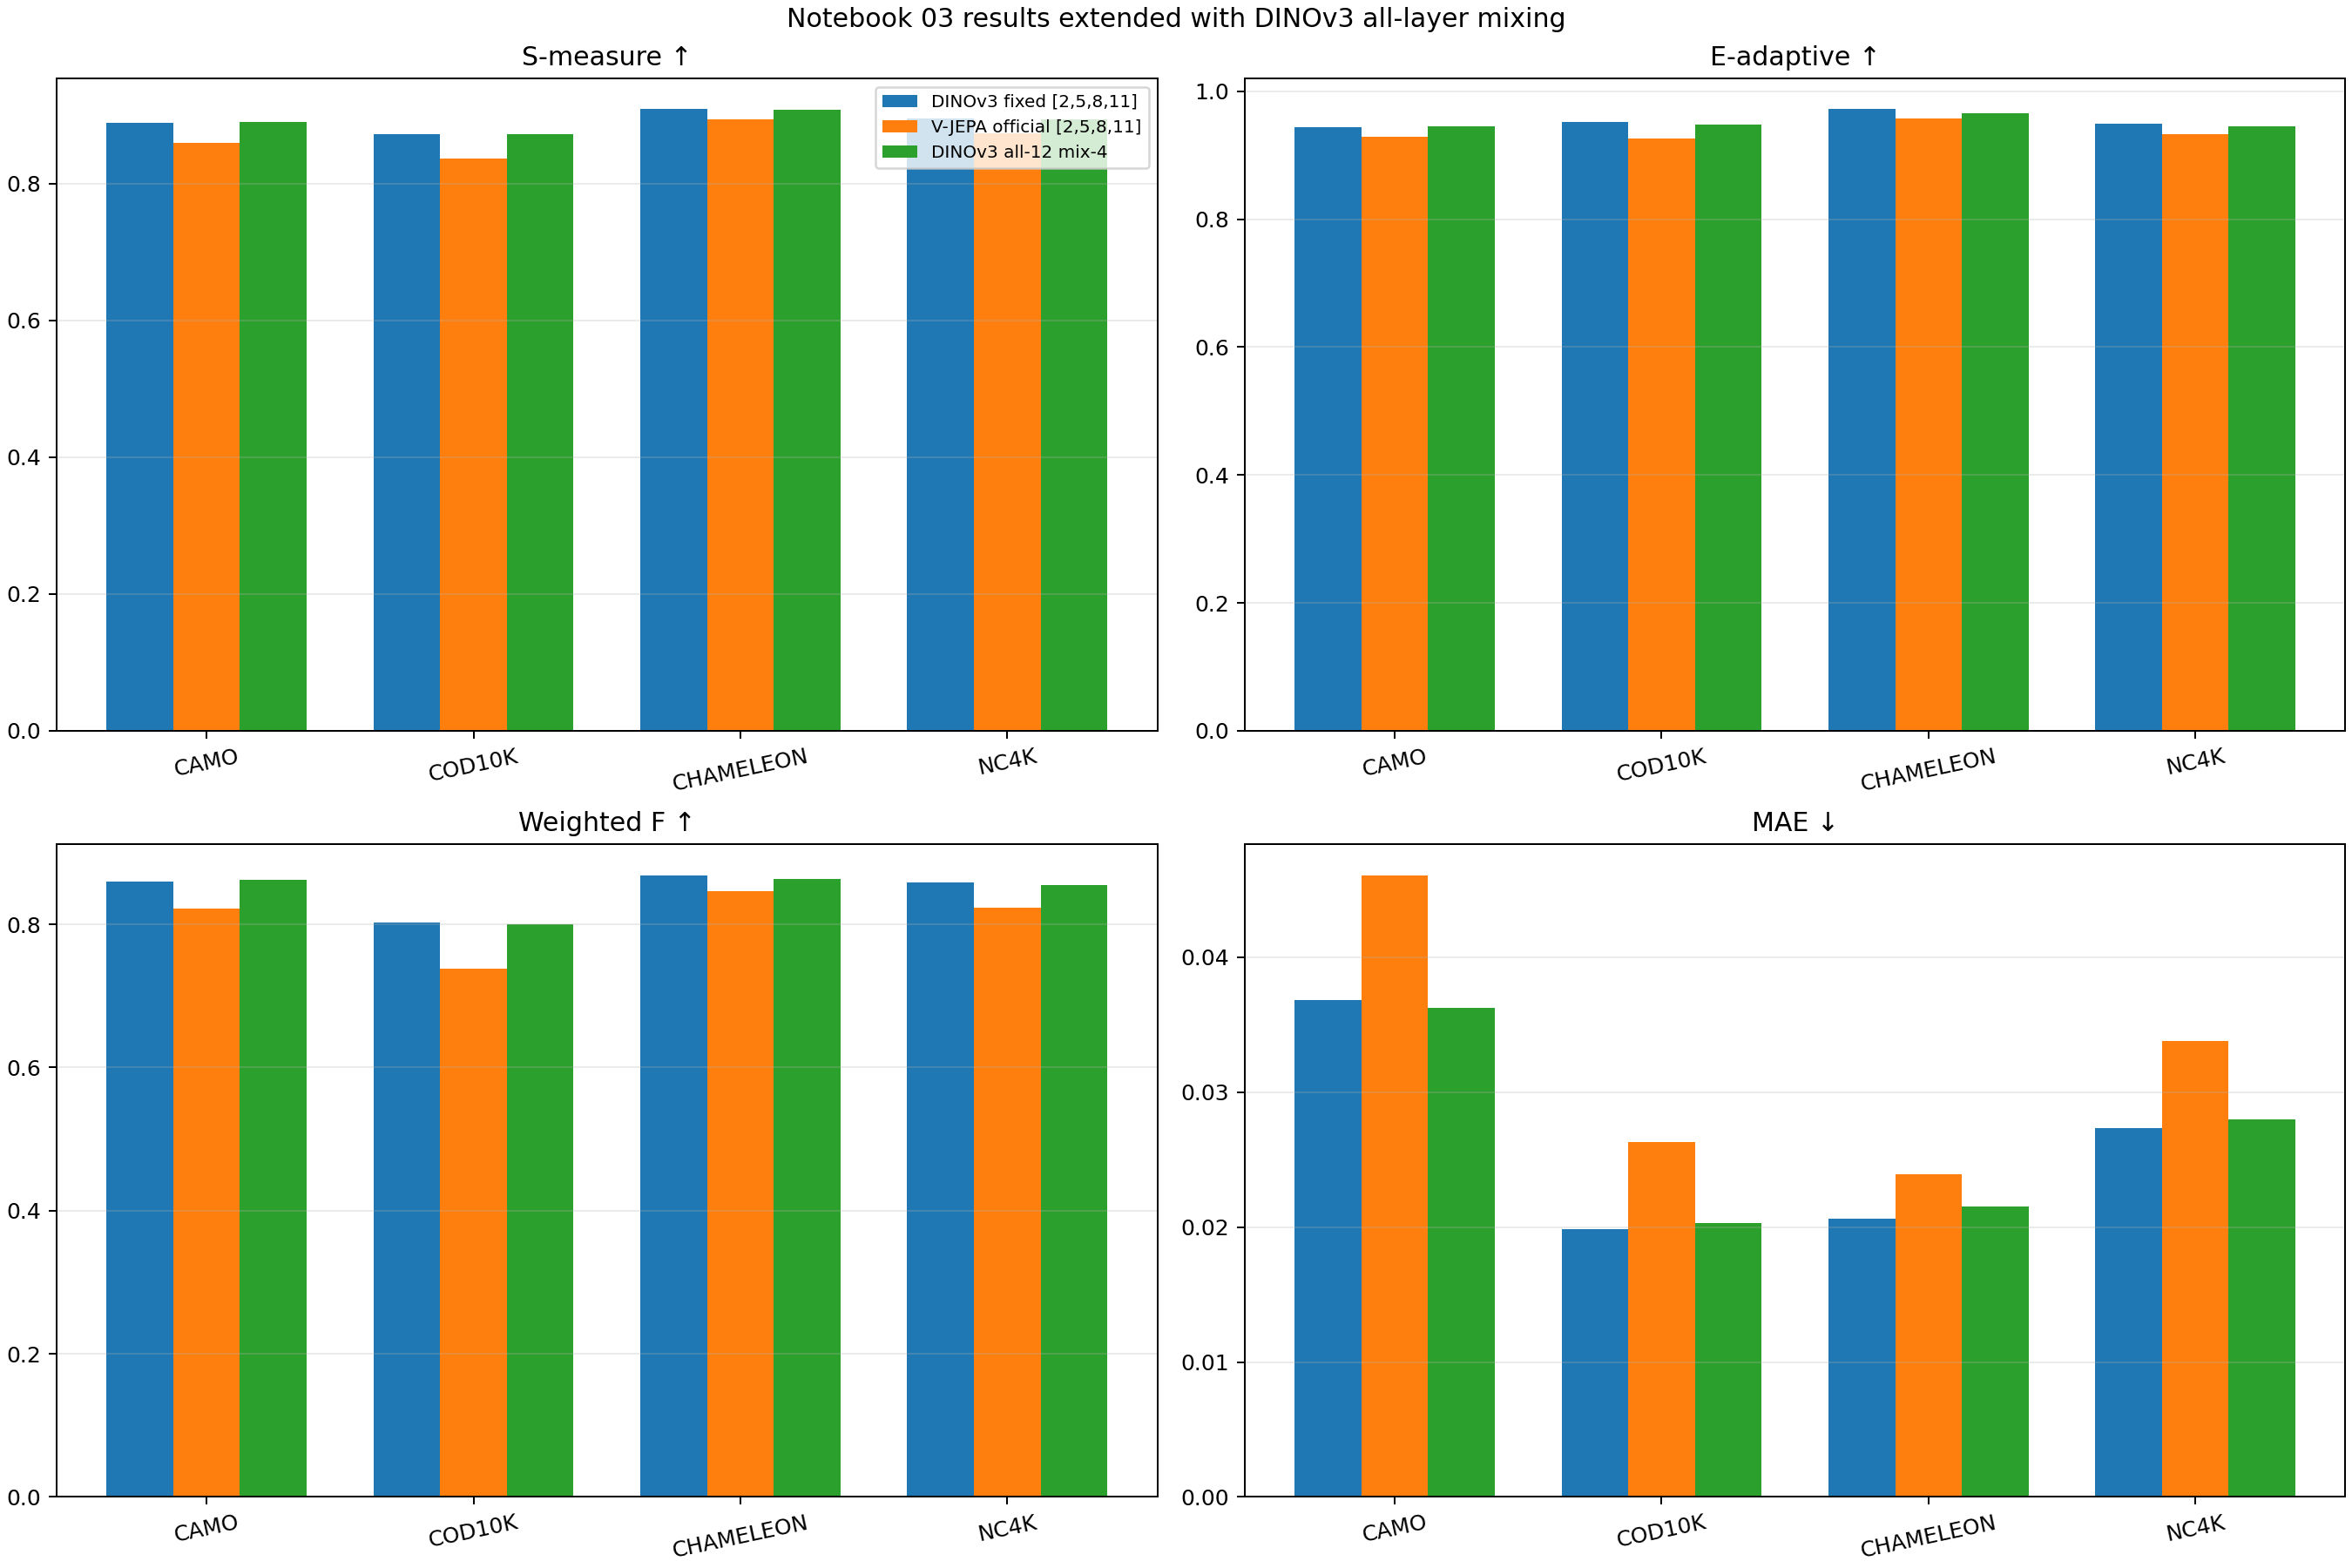

DINO ablation artifacts: /content/drive/MyDrive/cod-ssl/comparisons/phase1_seed42_all12_mix4_dinov3_ablation
Extended notebook-03 analysis: /content/drive/MyDrive/cod-ssl/comparisons/phase1_seed42_all12_mix4_extended_03_results


In [8]:
# Extend notebook 03's two-model table with DINOv3 all-12, without overwriting it.
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from PIL import Image
EXTENDED_COMPARISON.mkdir(parents=True, exist_ok=True)
RUNS = {
    'DINOv3 fixed [2,5,8,11]': FIXED_DINO_RUN,
    'V-JEPA official [2,5,8,11]': FIXED_VJEPA_RUN,
    'DINOv3 all-12 mix-4': DINO_RUN,
}
rows = []
for model, run in RUNS.items():
    results = json.loads((run / 'metrics.json').read_text())
    for dataset in ('camo_test','cod10k_test','chameleon','nc4k'):
        values = results[dataset]
        rows.append({'model': model, 'dataset': dataset,
                     **{key: values[key] for key in ('s_measure','e_adaptive','weighted_f','mae')},
                     'inference_ms_per_image': values['inference_ms_per_image']})
extended = pd.DataFrame(rows)
extended.to_csv(EXTENDED_COMPARISON / 'extended_comparison_metrics.csv', index=False)
metrics = [('s_measure','S-measure ↑'), ('e_adaptive','E-adaptive ↑'),
           ('weighted_f','Weighted F ↑'), ('mae','MAE ↓')]
figure, axes = plt.subplots(2, 2, figsize=(15, 10), constrained_layout=True)
x = np.arange(4); width = 0.25
for axis, (metric, title) in zip(axes.flat, metrics):
    for index, model in enumerate(RUNS):
        values = extended[extended.model == model].set_index('dataset').loc[['camo_test','cod10k_test','chameleon','nc4k'], metric]
        axis.bar(x + (index - 1) * width, values, width, label=model)
    axis.set_title(title); axis.set_xticks(x, ['CAMO','COD10K','CHAMELEON','NC4K'], rotation=12); axis.grid(axis='y', alpha=.25)
axes[0,0].legend(fontsize=8)
figure.suptitle('Notebook 03 results extended with DINOv3 all-layer mixing')
figure.savefig(EXTENDED_COMPARISON / 'extended_metric_comparison.png', dpi=180)
plt.close(figure)
display(extended)
display(Image.open(DINO_RUN / 'layer_mixture/layer_mixture_heatmap.png'))
display(Image.open(DINO_ABLATION / 'metric_comparison.png'))
display(Image.open(EXTENDED_COMPARISON / 'extended_metric_comparison.png'))
print('DINO ablation artifacts:', DINO_ABLATION)
print('Extended notebook-03 analysis:', EXTENDED_COMPARISON)
os.sync()